# Invigilator Assignment Problem (IAP) — Multi-Factor ILP

**Course:** CO2011 Mathematical Modeling — Semester 252, HCMUT


**Approach:** Role-aware Integer Linear Programming via OR-Tools CP-SAT

### Notebook map

| Part | Title | Maps to assignment Req. |
|---|---|---|
| 0 | Front matter & setup | — |
| 1 | Data ingestion & exploration | 6 |
| 2 | Domain analysis: roles, campuses, baseline workload | 1, 6 |
| 3 | Synthetic data: locations + explicit preferences | 6 |
| 4 | ILP — sets, parameters, decision variables | 1, 2 |
| 5 | ILP — multi-factor objective function | 3 |
| 6 | ILP — hard & soft constraints | 4, 5 |
| 7 | Solver build (CP-SAT) & initial solve | 7 |
| 8 | Tuning, relaxation, α-weight grid | 8 |
| 9 | Performance analysis vs. baseline | 9 |
| 10 | Extensions | 10 |




## Part 0 — Environment setup



In [1]:
!pip install ortools


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Standard scientific stack
import os, json, time, random
from collections import defaultdict, Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ortools.sat.python import cp_model

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Paths
ROOT_DIR = Path.cwd()

DATA_DIR = ROOT_DIR / "data"
FIG_DIR  = ROOT_DIR / "figures"
OUT_DIR  = ROOT_DIR / "outputs"

DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

DATA_FILE = "data/Dataset_Anonymized_Invigilator_Assignment_Problem.xlsx"

print("Project root:", ROOT_DIR)
print("Figures dir:", FIG_DIR)
print("Outputs dir:", OUT_DIR)

# Display
pd.set_option("display.max_rows", 30)
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 120, "font.size": 10})
print("Environment ready. OR-Tools version:", cp_model.CpSolverSolutionCallback.__module__)

Project root: C:\Users\Admin\Desktop\MyProject\AS_MM
Figures dir: C:\Users\Admin\Desktop\MyProject\AS_MM\figures
Outputs dir: C:\Users\Admin\Desktop\MyProject\AS_MM\outputs
Environment ready. OR-Tools version: ortools.sat.python.cp_model


---

## Part 1 — Data Ingestion & Exploration


The course provides an **anonymized baseline schedule** from HCMUT Faculty of CSE.
The file is *not just input data* — it is also the **baseline solution** we must improve on (Req. 9).

We load it, inspect the schema, validate completeness, and surface descriptive statistics.

In [3]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
df_raw = pd.read_excel(DATA_FILE)
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (769, 9)


,Ca thi,Ngày,GIỜ,MS Ca thi,Nhiệm vụ,MS của CÁN BỘ COI THI,Thời gian,Thứ,Cơ sở
0,"Thứ 2, 18/05/2026, Ca 5: 18g15-20g45",2026-05-18,18g15,20260518_5,LTK_CBCT,CB001,150,Thứ 2,Cơ sở 1
1,"Thứ 2, 18/05/2026, Ca 5: 18g15-20g45",2026-05-18,18g15,20260518_5,LTK_CBCT,CB002,150,Thứ 2,Cơ sở 1
2,"Thứ 3, 19/05/2026, Ca 5: 18g15-20g45",2026-05-19,18g15,20260519_5,LTK_CBCT,CB003,150,Thứ 3,Cơ sở 1
3,"Thứ 3, 19/05/2026, Ca 5: 18g15-20g45",2026-05-19,18g15,20260519_5,LTK_CBCT,CB004,150,Thứ 3,Cơ sở 1
4,"Thứ 3, 19/05/2026, Ca 5: 18g15-20g45",2026-05-19,18g15,20260519_5,LTK_CBCT,CB005,150,Thứ 3,Cơ sở 1


### 1.1 Schema & data dictionary

| Column (Vietnamese) | English meaning | Type |
|---|---|---|
| `Ca thi` | Human-readable shift label (day-of-week, date, slot range) | str |
| `Ngày` | Date | datetime |
| `GIỜ` | Time-of-day code (`07g00`, `09g30`, `13g00`, `15g30`, `18g15`) | str |
| `MS Ca thi` | Shift ID (`YYYYMMDD_slot`) — **primary key for shifts** | str |
| `Nhiệm vụ` | Duty type (`{LTK\|DiAn}_{CBCT\|Thư ký\|Trưởng HĐ}`) | str |
| `MS của CÁN BỘ COI THI` | Invigilator ID (`CB001`–`CB073`) — **primary key for staff** | str |
| `Thời gian` | Shift duration in minutes (constant = 150) | int |
| `Thứ` | Day of week (Vietnamese) | str |
| `Cơ sở` | Campus: `Cơ sở 1` = LTK (Lý Thường Kiệt, central HCMC) ; `Cơ sở 2` = Dĩ An (Bình Dương) | str |

In [5]:
print("Distinct values per column:")
print(df_raw.nunique())
print("\nMissing values:")
print(df_raw.isna().sum())

Distinct values per column:
Ca thi                   65
Ngày                     23
GIỜ                       5
MS Ca thi                65
Nhiệm vụ                  6
MS của CÁN BỘ COI THI    73
Thời gian                 1
Thứ                       7
Cơ sở                     2
dtype: int64

Missing values:
Ca thi                    0
Ngày                      0
GIỜ                       0
MS Ca thi                 0
Nhiệm vụ                  0
MS của CÁN BỘ COI THI     0
Thời gian                 0
Thứ                      28
Cơ sở                    28
dtype: int64


In [6]:
# Extract role from Nhiệm vụ → "<campus_prefix>_<role>"
df = df_raw.copy()
df["role_raw"] = df["Nhiệm vụ"].str.split("_").str[1]
ROLE_MAP = {"CBCT": "CBCT", "Thư ký": "TK", "Trưởng HĐ": "CHAIR"}
df["role"]   = df["role_raw"].map(ROLE_MAP)
df["campus"] = df["Cơ sở"].map({"Cơ sở 1": 1, "Cơ sở 2": 2})
df[["MS Ca thi", "MS của CÁN BỘ COI THI", "role", "campus", "Ngày", "GIỜ"]].head()

,MS Ca thi,MS của CÁN BỘ COI THI,role,campus,Ngày,GIỜ
0,20260518_5,CB001,CBCT,1.0,2026-05-18,18g15
1,20260518_5,CB002,CBCT,1.0,2026-05-18,18g15
2,20260519_5,CB003,CBCT,1.0,2026-05-19,18g15
3,20260519_5,CB004,CBCT,1.0,2026-05-19,18g15
4,20260519_5,CB005,CBCT,1.0,2026-05-19,18g15


### 1.2 Shift-level descriptive statistics

In [7]:
shift_demand = df.groupby("MS Ca thi").size()
print("Number of distinct shifts:", shift_demand.shape[0])
print("Total assignments (baseline):", df.shape[0])
print("\nDemand per shift (#invigilators needed):")
print(shift_demand.describe().round(2))

Number of distinct shifts: 65
Total assignments (baseline): 769

Demand per shift (#invigilators needed):
count    65.00
mean     11.83
std      12.41
min       1.00
25%       2.00
50%       4.00
75%      22.00
max      35.00
dtype: float64


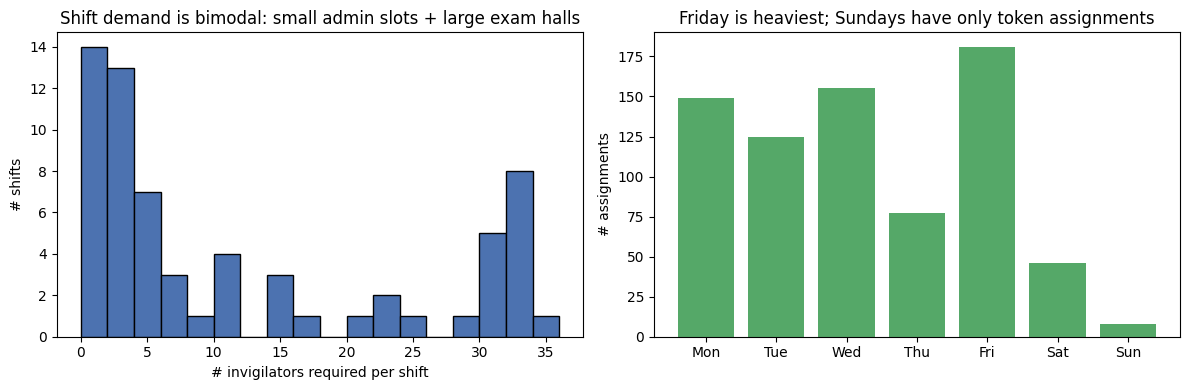

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of shift demand
axes[0].hist(shift_demand.values, bins=range(0, 38, 2), edgecolor="black", color="#4C72B0")
axes[0].set_xlabel("# invigilators required per shift")
axes[0].set_ylabel("# shifts")
axes[0].set_title("Shift demand is bimodal: small admin slots + large exam halls")

# Day-of-week distribution
dow_order = ["Thứ 2", "Thứ 3", "Thứ 4", "Thứ 5", "Thứ 6", "Thứ 7", "Chủ Nhật"]
dow_counts = df["Thứ"].value_counts().reindex(dow_order).fillna(0)
axes[1].bar(range(len(dow_order)), dow_counts.values, color="#55A868")
axes[1].set_xticks(range(len(dow_order)))
axes[1].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], rotation=0)
axes[1].set_ylabel("# assignments")
axes[1].set_title("Friday is heaviest; Sundays have only token assignments")

plt.tight_layout()
plt.savefig(FIG_DIR / "01_demand_and_dow.png", bbox_inches="tight")
plt.show()

### 1.3 Observations
- 73 invigilators, 65 shifts, 769 assignments over 23 days (May 18 → Jun 13, 2026 — about 4 weeks).
- Demand is bimodal: 14 shifts need only 1 person (admin-only) while 13 shifts need ≥30 (multi-room midterms/finals).
- Friday concentration suggests a courseload-driven exam pattern; Sundays are mostly empty.
- All shifts last 150 minutes; the 5 daily time slots are tightly packed but non-overlapping.

---

## Part 2 — Domain Analysis: Roles, Campuses, Baseline Workload


The naive read of the IAP brief treats invigilators as homogeneous and minimizes variance.
The data tells a richer story. We decode three distinct **role types** and three derived
**seniority tiers** from the baseline schedule itself — no synthetic guesswork.

### 2.1 Role types — what `Nhiệm vụ` actually encodes

| Role | Vietnamese | English | Authority |
|---|---|---|---|
| `CBCT` | Cán Bộ Coi Thi | Regular Proctor | base invigilator pool |
| `TK`   | Thư ký | Secretary | clerical/admin track |
| `CHAIR`| Trưởng HĐ | Council Chair | most senior, board authority |

In [9]:
role_counts = df["role"].value_counts()
print("Assignments by role:")
print(role_counts)
print(f"\nTotal: {role_counts.sum()}")

Assignments by role:
role
CBCT     716
TK        35
CHAIR     18
Name: count, dtype: int64

Total: 769


### 2.2 Deriving seniority TIER from duty history

A CB's *tier* is defined by which roles they've **ever** been assigned:

- `SENIOR` ↔ has done CHAIR (and CBCT)
- `MID`    ↔ has done TK (and CBCT) but never CHAIR
- `JUNIOR` ↔ has only done CBCT

This partitions the 73 invigilators **exactly** — no overlap, no synthetic randomness.

In [10]:
cb_roles = df.groupby("MS của CÁN BỘ COI THI")["role"].apply(set).to_dict()

def derive_tier(role_set):
    if "CHAIR" in role_set: return "SENIOR"
    if "TK"    in role_set: return "MID"
    return "JUNIOR"

TIER = {cb: derive_tier(s) for cb, s in cb_roles.items()}
tier_counts = pd.Series(TIER).value_counts()[["SENIOR", "MID", "JUNIOR"]]
print("Seniority tier distribution (derived from data):")
print(tier_counts)

Seniority tier distribution (derived from data):
SENIOR     5
MID       20
JUNIOR    48
Name: count, dtype: int64


### 2.3 Baseline workload per invigilator — this is what we improve on

Baseline workload summary:
count    73.00
mean     10.53
std       2.22
min       3.00
25%       9.00
50%      11.00
75%      12.00
max      19.00
Name: shifts, dtype: float64

By tier:
        count   mean   std  min   25%   50%    75%   max
tier                                                    
JUNIOR   48.0  10.04  2.05  3.0   9.0  10.0  11.25  13.0
MID      20.0  12.05  2.16  9.0  11.0  11.5  13.00  19.0
SENIOR    5.0   9.20  0.84  8.0   9.0   9.0  10.00  10.0


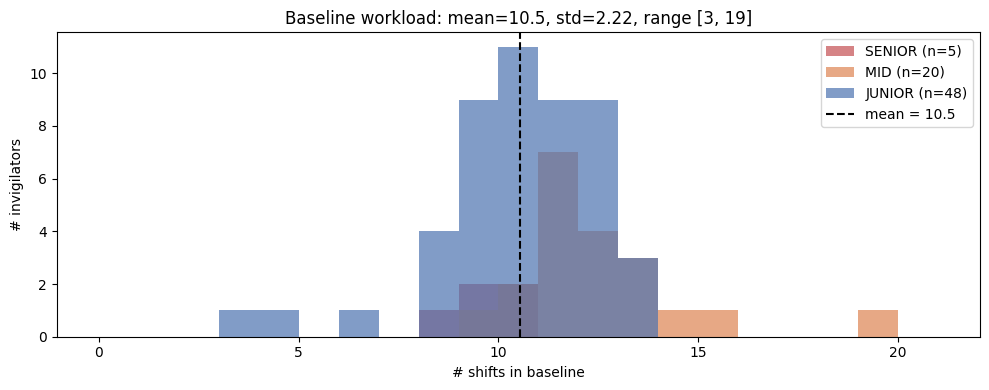

In [11]:
workload_baseline = df.groupby("MS của CÁN BỘ COI THI").size().rename("shifts")
wb = workload_baseline.to_frame().reset_index()
wb["tier"] = wb["MS của CÁN BỘ COI THI"].map(TIER)

print("Baseline workload summary:")
print(workload_baseline.describe().round(2))
print("\nBy tier:")
print(wb.groupby("tier")["shifts"].describe().round(2))

fig, ax = plt.subplots(figsize=(10, 4))
colors = {"SENIOR": "#C44E52", "MID": "#DD8452", "JUNIOR": "#4C72B0"}
for t in ["SENIOR", "MID", "JUNIOR"]:
    vals = wb[wb["tier"] == t]["shifts"]
    ax.hist(vals, bins=range(0, 22), alpha=0.7, label=f"{t} (n={len(vals)})", color=colors[t])
ax.axvline(workload_baseline.mean(), color="black", linestyle="--",
           label=f"mean = {workload_baseline.mean():.1f}")
ax.set_xlabel("# shifts in baseline")
ax.set_ylabel("# invigilators")
ax.set_title(f"Baseline workload: mean={workload_baseline.mean():.1f}, "
             f"std={workload_baseline.std():.2f}, range [{workload_baseline.min()}, {workload_baseline.max()}]")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "02_baseline_workload.png", bbox_inches="tight")
plt.show()

### 2.4 Domain summary

| Metric | Value | Implication |
|---|---|---|
| Distinct invigilators | 73 | Modest-scale ILP, exact solve feasible |
| Distinct shifts | 65 | Includes 14 single-staff admin slots |
| Total assignments (baseline) | 769 | Demand we must meet exactly |
| Date range | 23 days | Need fatigue rule (≤2 consecutive days) |
| Baseline workload std | ≈ 2.22 | Headroom for fairness improvement |
| Baseline workload range | [3, 19] | One person did 19 shifts in 4 weeks |
| SENIOR tier | 5 staff | Bottleneck: only they can chair |
| MID tier | 20 staff | Cover TK + CBCT slots |
| JUNIOR tier | 48 staff | Bulk pool for CBCT |

---

## Part 3 — Synthetic Data: Location Preferences & Explicit Preferences


The assignment brief asks us to **simulate location preferences** (NEAR_CS1 / NEAR_CS2 / BALANCED) and
incorporate them. We seed the synthesis from the baseline schedule itself so the model is realistic.

### 3.1 Location preference per invigilator

Each invigilator's home location is inferred from their **observed campus mix in the baseline**:

- ≥ 80 % at Cơ sở 1 → `NEAR_CS1`
- ≥ 80 % at Cơ sở 2 → `NEAR_CS2`
- otherwise → `BALANCED`

This grounds the synthetic attribute in observed behaviour rather than a uniform random draw.

In [12]:
camp_mix = (df.groupby("MS của CÁN BỘ COI THI")["Cơ sở"]
              .value_counts(normalize=True).unstack(fill_value=0))

def loc_from_mix(row):
    cs1 = row.get("Cơ sở 1", 0); cs2 = row.get("Cơ sở 2", 0)
    if cs1 >= 0.80: return "NEAR_CS1"
    if cs2 >= 0.80: return "NEAR_CS2"
    return "BALANCED"

LOC = {cb: loc_from_mix(camp_mix.loc[cb]) for cb in camp_mix.index}
print("Location preference distribution:")
print(pd.Series(LOC).value_counts())

Location preference distribution:
BALANCED    57
NEAR_CS2    11
NEAR_CS1     5
Name: count, dtype: int64


### 3.2 Explicit preference $\mathrm{pref}_{ij} \in [0, 100]$

We synthesize a per-(invigilator, shift) preference score with a documented rule:

$$
\mathrm{pref}_{ij} = 50 + 20 \cdot \mathbb{1}[\text{same campus}] + 15 \cdot \mathbb{1}[(i,j) \in \text{baseline}] + \varepsilon, \quad \varepsilon \sim U[-10, +10]
$$

then clip to $[0, 100]$. This rewards historic matches and same-campus alignment.

In [13]:
shift_meta = {}
for j, g in df.groupby("MS Ca thi"):
    row = g.iloc[0]
    shift_meta[j] = {
        "date":   row["Ngày"],
        "time":   row["GIỜ"],
        "dow":    row["Thứ"],
        "campus": 1 if row["Cơ sở"] == "Cơ sở 1" else 2,
    }

INVIGS = sorted(df["MS của CÁN BỘ COI THI"].unique())
SHIFTS = sorted(df["MS Ca thi"].unique())
hist_pairs = set(zip(df["MS của CÁN BỘ COI THI"], df["MS Ca thi"]))

random.seed(SEED)
PREF = {i: {} for i in INVIGS}
for i in INVIGS:
    for j in SHIFTS:
        base = 50
        if (LOC[i] == "NEAR_CS1" and shift_meta[j]["campus"] == 1) or \
           (LOC[i] == "NEAR_CS2" and shift_meta[j]["campus"] == 2):
            base += 20
        if (i, j) in hist_pairs:
            base += 15
        base += random.randint(-10, 10)
        PREF[i][j] = max(0, min(100, base))

# Distribution sanity check
flat = [PREF[i][j] for i in INVIGS for j in SHIFTS]
print(f"pref distribution: mean={np.mean(flat):.1f}, std={np.std(flat):.1f}, "
      f"min={min(flat)}, max={max(flat)}, n={len(flat)}")

pref distribution: mean=54.7, std=10.7, min=40, max=95, n=4745


### 3.3 Persist parameters for reproducibility

In [14]:
params_out = {
    "seed": SEED,
    "n_invigilators": len(INVIGS),
    "n_shifts": len(SHIFTS),
    "tier_distribution": {k: int(v) for k, v in pd.Series(TIER).value_counts().items()},
    "location_distribution": {k: int(v) for k, v in pd.Series(LOC).value_counts().items()},
    "baseline_workload": {
        "mean": float(workload_baseline.mean()),
        "std":  float(workload_baseline.std()),
        "min":  int(workload_baseline.min()),
        "max":  int(workload_baseline.max()),
    },
    "synthesis_rules": {
        "tier":     "from data: CHAIR→SENIOR, TK→MID, else JUNIOR",
        "location": "≥80% baseline campus share → NEAR_CSx, else BALANCED",
        "pref":     "50 + 20·same_campus + 15·hist_pair + U[-10,10], clipped to [0,100]",
    },
}
with open(OUT_DIR / "params.json", "w", encoding="utf-8") as f:
    json.dump(params_out, f, indent=2, ensure_ascii=False)
print("Saved params.json")

Saved params.json


---

## Part 4 — ILP Formulation: Sets, Parameters, Decision Variables


We now formalize the model. Numbers are filled in directly from the dataset to keep the notebook self-contained.

### 4.1 Sets

| Symbol | Meaning | Cardinality |
|---|---|---|
| $I$  | invigilators $\{CB_{001}, \dots, CB_{073}\}$ | 73 |
| $J$  | exam shifts (one per `MS Ca thi`) | 65 |
| $R$  | role slot types $\{\text{CBCT}, \text{TK}, \text{CHAIR}\}$ | 3 |
| $T$  | seniority tiers $\{\text{SENIOR}, \text{MID}, \text{JUNIOR}\}$ | 3 |
| $L$  | home-location groups $\{\text{NEAR\_CS1}, \text{NEAR\_CS2}, \text{BALANCED}\}$ | 3 |
| $D$  | distinct calendar days | 23 |
| $S$  | (date, time) buckets — any two shifts in the same bucket conflict | ≤ 65 |

### 4.2 Parameters

| Symbol | Definition | Source |
|---|---|---|
| $\mathrm{tier}(i) \in T$ | seniority tier of invigilator $i$ | derived from baseline (§2.2) |
| $\mathrm{loc}(i) \in L$ | home location of $i$ | inferred from baseline campus mix (§3.1) |
| $\mathrm{campus}(j) \in \{1,2\}$ | campus of shift $j$ | from `Cơ sở` |
| $d_{j,r}$ | # of role-$r$ slots needed at shift $j$ | counted from `Nhiệm vụ` |
| $\mathrm{cap}_t$ | weekly cap for tier $t$ over full 4-week window | policy parameter (8 / 16 / 18) |
| $\mathrm{pay}_r$ | integer pay weight per slot of role $r$ | policy (15 / 12 / 10) |
| $\mathrm{pref}_{ij} \in [0,100]$ | explicit preference | synthesized (§3.2) |
| $\mathrm{cross}(i,j) \in \{0,1\}$ | 1 iff invigilator $i$ would be crossing campus to attend $j$ | derived |
| $\mathrm{target}_t$ | per-tier expected workload (role-normalized fairness target) | derived (§4.3) |
| $\mathrm{elig}(i,r) \in \{0,1\}$ | 1 iff $i$ is eligible for role $r$ (CHAIR↔SENIOR, TK↔MID, CBCT↔any) | derived from $\mathrm{tier}(i)$ |

In [15]:
# Concrete parameter values
ROLES = ["CBCT", "TK", "CHAIR"]
PAY = {"CHAIR": 15, "TK": 12, "CBCT": 10}
CAP_TIER = {"SENIOR": 8, "MID": 16, "JUNIOR": 18}

# Shift demand per role
demand = {}
for j, g in df.groupby("MS Ca thi"):
    demand[j] = {r: int((g["role"] == r).sum()) for r in ROLES}

# Total demand per role
total_demand_per_role = {r: sum(demand[j][r] for j in SHIFTS) for r in ROLES}
print("Demand per role across all shifts:", total_demand_per_role)
print("Grand total:", sum(total_demand_per_role.values()))

Demand per role across all shifts: {'CBCT': 716, 'TK': 35, 'CHAIR': 18}
Grand total: 769


### 4.3 Target workload per tier — role-normalized fairness target

A SENIOR doing 2 shifts is fine; a JUNIOR doing 2 shifts is underused.
We define a tier-specific target proportional to the tier's capacity budget:

$$
\mathrm{target}_t \;=\; \frac{\mathrm{cap}_t \cdot n_t}{\sum_{t'} \mathrm{cap}_{t'} \cdot n_{t'}} \cdot \frac{\sum_{j,r} d_{j,r}}{n_t}
$$

so the targets sum (weighted by tier headcount) to total demand.

In [16]:
tier_count = pd.Series(TIER).value_counts().to_dict()
total_demand = sum(total_demand_per_role.values())
cap_budget   = {t: CAP_TIER[t] * tier_count[t] for t in CAP_TIER}
total_cap    = sum(cap_budget.values())
TARGET = {t: (cap_budget[t] / total_cap) * total_demand / tier_count[t] for t in CAP_TIER}

print("Per-tier target shifts (rounded):")
for t in ["SENIOR", "MID", "JUNIOR"]:
    print(f"  {t:8s}  target={TARGET[t]:5.2f}  cap={CAP_TIER[t]}  n={tier_count[t]}")

Per-tier target shifts (rounded):
  SENIOR    target= 5.03  cap=8  n=5
  MID       target=10.05  cap=16  n=20
  JUNIOR    target=11.31  cap=18  n=48


### 4.4 Decision variables

| Variable | Domain | Meaning |
|---|---|---|
| $x_{ijr} \in \{0,1\}$ | binary | $1$ iff invigilator $i$ fills a role-$r$ slot at shift $j$ |
| $y_{id} \in \{0,1\}$ | binary | $1$ iff $i$ works any shift on day $d$ (fatigue indicator) |
| $z_{id} \in \{0,1\}$ | binary | $1$ iff $i$ works $\geq 2$ shifts on day $d$ (same-day double) |
| $w_{id} \in \{0,1\}$ | binary | $1$ iff days $d, d+1, d+2$ are all working days (3-in-a-row) |
| $u_i, o_i \in \mathbb{Z}_{\geq 0}$ | non-negative int | under/over-target slack: $\sum_{j,r} x_{ijr} - \mathrm{target}_{\mathrm{tier}(i)} = o_i - u_i$ |

We **omit** $x_{ijr}$ for ineligible $(i, r)$ pairs to shrink the model. Effective count below.

In [17]:
def eligible(i, r):
    t = TIER[i]
    if r == "CHAIR": return t == "SENIOR"
    if r == "TK":    return t == "MID"
    return True  # CBCT — anyone

raw_xs    = len(INVIGS) * len(SHIFTS) * len(ROLES)
trimmed_xs = sum(eligible(i, r) for i in INVIGS for r in ROLES) * len(SHIFTS)
print(f"x_ijr raw possible:  {raw_xs:,}")
print(f"x_ijr after eligibility trim: {trimmed_xs:,}  ({100*trimmed_xs/raw_xs:.0f}% kept)")

x_ijr raw possible:  14,235
x_ijr after eligibility trim: 6,370  (45% kept)


---

## Part 5 — Multi-Factor Objective Function


The toy formulation in the brief minimizes a single term — workload variance.
That is unrealistic: it implies all 73 invigilators should do the same number of shifts,
ignores travel cost, ignores pay, ignores preferences. We replace it with a **weighted sum of five terms**:

$$
\min Z \;=\; \alpha_1 \cdot \underbrace{\sum_{i \in I}(u_i + o_i)}_{\text{FAIRNESS}}
\;+\; \alpha_2 \cdot \underbrace{\sum_{i,j,r} \mathrm{cross}(i,j) \cdot x_{ijr}}_{\text{TRAVEL}}
\;+\; \alpha_3 \cdot \underbrace{\Big(\sum_{i,d} z_{id} + \sum_{i,d} w_{id}\Big)}_{\text{FATIGUE}}
\;+\; \alpha_4 \cdot \underbrace{\sum_{i,j,r} \mathrm{pay}_r \cdot x_{ijr}}_{\text{COST}}
\;-\; \alpha_5 \cdot \underbrace{\sum_{i,j,r} \mathrm{pref}_{ij} \cdot x_{ijr}}_{\text{PREF}}
$$

### 5.1 Starting weight vector and its justification

| Weight | Value | Why |
|---|---|---|
| $\alpha_1$ FAIRNESS | 10 | Primary objective — equitable workload |
| $\alpha_2$ TRAVEL | 5 | Strong soft incentive (locations matter) but not absolute |
| $\alpha_3$ FATIGUE | 8 | Health/safety — heavy penalty for double-booking same day |
| $\alpha_4$ COST | 1 | Always present, but secondary to fairness/health |
| $\alpha_5$ PREF | 1 | Bonus — magnitudes already at 50–100 scale, so weight kept small |

The α-vector is tuned empirically in Part 8 via a grid search on the Pareto frontier of
**(fairness, travel, cost)** trade-offs.

In [18]:
ALPHA = {"FAIR": 10, "TRAVEL": 5, "FATIGUE": 8, "COST": 1, "PREF": 1}
print("Starting α vector:", ALPHA)

Starting α vector: {'FAIR': 10, 'TRAVEL': 5, 'FATIGUE': 8, 'COST': 1, 'PREF': 1}


---

## Part 6 — Hard and Soft Constraints

**Owner:** Hung · **Reviewer:** Quoc · **Maps to:** Req. 4, 5

### 6.1 Hard constraints

| # | Description | Mathematical form |
|---|---|---|
| **H1** | Demand met per shift per role | $\sum_{i} x_{ijr} = d_{j,r}, \quad \forall j \in J, \forall r \in R$ |
| **H2** | Eligibility (tier–role compatibility) | $x_{ijr} = 0 \text{ if } \neg \mathrm{elig}(i, r)$ |
| **H3** | One role per shift per person | $\sum_{r} x_{ijr} \leq 1, \quad \forall i, j$ |
| **H4** | No overlap in same (date, time) bucket | $\sum_{j \in s, r} x_{ijr} \leq 1, \quad \forall i, s \in S$ |
| **H5** | Per-tier workload cap | $\sum_{j, r} x_{ijr} \leq \mathrm{cap}_{\mathrm{tier}(i)}, \quad \forall i$ |
| **H6** | Day indicator link | $y_{id} = \max_{j \in \mathrm{day}(d)}\!\sum_{r} x_{ijr}$ |
| **H7** | Same-day double link | $z_{id} = 1 \Leftrightarrow \sum_{j \in \mathrm{day}(d), r} x_{ijr} \geq 2$ |
| **H8** | 3-in-a-row link | $w_{id} \geq y_{id} + y_{i,d+1} + y_{i,d+2} - 2$ |

### 6.2 Soft constraints (already in $Z$ as penalties)

| # | Soft rule | Penalty term in $Z$ |
|---|---|---|
| **S1** | Honor location preference | $\alpha_2 \cdot \text{TRAVEL}$ |
| **S2** | Avoid 3-day streaks | $\alpha_3 \cdot \sum_{i,d} w_{id}$ |
| **S3** | Avoid same-day doubles | $\alpha_3 \cdot \sum_{i,d} z_{id}$ |
| **S4** | Reward high explicit preferences | $-\alpha_5 \cdot \text{PREF}$ |
| **S5** | Minimize total payroll | $\alpha_4 \cdot \text{COST}$ |




---

## Part 7 — Solver Implementation (OR-Tools CP-SAT)


### 7.1 Why CP-SAT
- Same expressive power as MILP for binary problems, but with **lazy clause generation** that often outperforms classic branch-and-cut on structured scheduling problems.
- Native support for `MaxEquality`, `OnlyEnforceIf`, integer-domain auxiliary variables — no big-M reformulation needed.
- Multi-threaded by default; free; pip-installable.

### 7.2 Build helpers

In [19]:
# Helper: precompute (date,time) buckets
slot_of = {j: (shift_meta[j]["date"], shift_meta[j]["time"]) for j in SHIFTS}
bucket = defaultdict(list)
for j in SHIFTS:
    bucket[slot_of[j]].append(j)

all_dates = sorted({shift_meta[j]["date"] for j in SHIFTS})
date_to_idx = {d: k for k, d in enumerate(all_dates)}
n_D = len(all_dates)

def cross(i, j):
    # Indicator: would i be crossing campus to attend j?
    c = shift_meta[j]["campus"]
    if LOC[i] == "NEAR_CS1" and c == 2: return 1
    if LOC[i] == "NEAR_CS2" and c == 1: return 1
    return 0

print(f"|S| (time buckets) = {len(bucket)}")
print(f"|D| (distinct days) = {n_D}")

|S| (time buckets) = 65
|D| (distinct days) = 23


In [20]:
def build_model(alpha):
    # Construct the full CP-SAT model with the given alpha weights. Returns (model, vars-dict).
    m = cp_model.CpModel()
    idx_i = {i: k for k, i in enumerate(INVIGS)}
    idx_j = {j: k for k, j in enumerate(SHIFTS)}

    # x[i,j,r]
    x = {}
    for i in INVIGS:
        for j in SHIFTS:
            for r in ROLES:
                if eligible(i, r):
                    x[i, j, r] = m.NewBoolVar(f"x_{idx_i[i]}_{idx_j[j]}_{r}")

    # H1 Demand
    for j in SHIFTS:
        for r in ROLES:
            terms = [x[i, j, r] for i in INVIGS if eligible(i, r)]
            m.Add(sum(terms) == demand[j][r])

    # H3 At most one role per (i,j)
    for i in INVIGS:
        for j in SHIFTS:
            terms = [x[i, j, r] for r in ROLES if eligible(i, r)]
            if terms:
                m.Add(sum(terms) <= 1)

    # H4 Time-slot overlap
    for i in INVIGS:
        for sl, js in bucket.items():
            if len(js) <= 1: continue
            terms = [x[i, j, r] for j in js for r in ROLES if eligible(i, r)]
            m.Add(sum(terms) <= 1)

    # H5 Per-tier cap
    shifts_of = {i: [(j, r) for j in SHIFTS for r in ROLES if eligible(i, r)] for i in INVIGS}
    for i in INVIGS:
        m.Add(sum(x[i, j, r] for (j, r) in shifts_of[i]) <= CAP_TIER[TIER[i]])

    # H6 Day indicators
    y = {}
    for i in INVIGS:
        for d_idx, d in enumerate(all_dates):
            y[i, d_idx] = m.NewBoolVar(f"y_{idx_i[i]}_{d_idx}")
            shifts_on_d = [j for j in SHIFTS if shift_meta[j]["date"] == d]
            terms = [x[i, j, r] for j in shifts_on_d for r in ROLES if eligible(i, r)]
            if terms: m.AddMaxEquality(y[i, d_idx], terms)
            else:     m.Add(y[i, d_idx] == 0)

    # H7 Same-day double indicator
    z = {}
    for i in INVIGS:
        for d_idx, d in enumerate(all_dates):
            z[i, d_idx] = m.NewBoolVar(f"z_{idx_i[i]}_{d_idx}")
            shifts_on_d = [j for j in SHIFTS if shift_meta[j]["date"] == d]
            terms = [x[i, j, r] for j in shifts_on_d for r in ROLES if eligible(i, r)]
            if terms:
                m.Add(sum(terms) >= 2).OnlyEnforceIf(z[i, d_idx])
                m.Add(sum(terms) <= 1).OnlyEnforceIf(z[i, d_idx].Not())
            else:
                m.Add(z[i, d_idx] == 0)

    # Fairness slack
    u, o = {}, {}
    MAX_S = max(CAP_TIER.values()) + 5
    for i in INVIGS:
        u[i] = m.NewIntVar(0, MAX_S, f"u_{idx_i[i]}")
        o[i] = m.NewIntVar(0, MAX_S, f"o_{idx_i[i]}")
        tgt = int(round(TARGET[TIER[i]]))
        workload = sum(x[i, j, r] for (j, r) in shifts_of[i])
        m.Add(workload - tgt == o[i] - u[i])

    # H8 3-in-a-row penalty aux
    w3 = {}
    for i in INVIGS:
        for d_idx in range(n_D - 2):
            w3[i, d_idx] = m.NewIntVar(0, 1, f"w3_{idx_i[i]}_{d_idx}")
            m.Add(w3[i, d_idx] >= y[i, d_idx] + y[i, d_idx+1] + y[i, d_idx+2] - 2)

    # Objective
    fair    = sum(u[i] + o[i] for i in INVIGS)
    travel  = sum(cross(i, j) * x[i, j, r] for (i, j, r) in x)
    fatigue = sum(z.values()) + sum(w3.values())
    cost    = sum(PAY[r] * x[i, j, r] for (i, j, r) in x)
    pref    = sum(PREF[i][j] * x[i, j, r] for (i, j, r) in x)

    m.Minimize(alpha["FAIR"]   * fair    +
               alpha["TRAVEL"] * travel  +
               alpha["FATIGUE"]* fatigue +
               alpha["COST"]   * cost    -
               alpha["PREF"]   * pref)

    return m, x, y, z, w3, u, o

### 7.3 First solve with the starting α vector

In [21]:
def solve_and_extract(m, x, time_limit=30, workers=8, verbose=False):
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = time_limit
    solver.parameters.num_search_workers = workers
    solver.parameters.log_search_progress = verbose
    t0 = time.time()
    status = solver.Solve(m)
    dt = time.time() - t0

    rows = []
    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        for (i, j, r), var in x.items():
            if solver.Value(var) == 1:
                rows.append({"CB": i, "shift": j, "role": r,
                             "tier": TIER[i], "loc": LOC[i],
                             "campus": shift_meta[j]["campus"],
                             "date": str(shift_meta[j]["date"].date()),
                             "time": shift_meta[j]["time"]})
    return {"status": solver.StatusName(status),
            "objective": solver.ObjectiveValue() if rows else None,
            "wall_time": dt,
            "solution": pd.DataFrame(rows)}

print("Building model with starting α …")
model, xvars, *_ = build_model(ALPHA)
print(f"#binaries (x only): {len(xvars):,}")

print("\nSolving (30s budget) …")
result = solve_and_extract(model, xvars, time_limit=30)
print(f"Status: {result['status']}   wall_time: {result['wall_time']:.2f}s   obj: {result['objective']:.0f}")
print(f"Assignments produced: {len(result['solution'])} (baseline 769)")

Building model with starting α …
#binaries (x only): 6,370

Solving (30s budget) …
Status: OPTIMAL   wall_time: 22.87s   obj: -43983
Assignments produced: 769 (baseline 769)


### 7.4 Validate the solution

In [22]:
sol = result["solution"]

# Demand satisfied
ok_demand = all(
    (sol[(sol["shift"] == j) & (sol["role"] == r)].shape[0]) == demand[j][r]
    for j in SHIFTS for r in ROLES
)
# No tier–role violations
ok_elig = all(eligible(row.CB, row.role) for row in sol.itertuples())
# No (date,time) overlaps
ok_overlap = sol.groupby(["CB", "date", "time"]).size().max() <= 1
# Per-tier caps respected
counts = sol.groupby("CB").size()
ok_cap = all(counts.get(i, 0) <= CAP_TIER[TIER[i]] for i in INVIGS)

print(f"  H1 demand met:        {ok_demand}")
print(f"  H2 eligibility OK:    {ok_elig}")
print(f"  H4 no overlap:        {ok_overlap}")
print(f"  H5 caps respected:    {ok_cap}")

sol.to_csv(OUT_DIR / "solution.csv", index=False)
print(f"\nSaved solution.csv ({len(sol)} rows)")

  H1 demand met:        True
  H2 eligibility OK:    True
  H4 no overlap:        True
  H5 caps respected:    True

Saved solution.csv (769 rows)


### 7.5 Solver Audit Report

This section performs a detailed audit of the final CP-SAT solution.

The audit verifies:
- demand satisfaction,
- eligibility compliance,
- no overlapping assignments,
- workload-cap constraints.

Detailed audit results are also exported as CSV files for reproducibility.

In [23]:
def solver_audit_report(sol):

    audit_rows = []

    # H1 Demand
    for j in SHIFTS:
        for r in ROLES:

            required = demand[j][r]

            actual = sol[
                (sol["shift"] == j) &
                (sol["role"] == r)
            ].shape[0]

            audit_rows.append({
                "constraint": "H1 Demand",
                "item": f"shift={j}, role={r}",
                "required": required,
                "actual": actual,
                "status": "PASS" if actual == required else "FAIL"
            })

    # H2 Eligibility
    for row in sol.itertuples():

        passed = eligible(row.CB, row.role)

        audit_rows.append({
            "constraint": "H2 Eligibility",
            "item": f"CB={row.CB}, role={row.role}",
            "required": "eligible",
            "actual": passed,
            "status": "PASS" if passed else "FAIL"
        })

    # H4 No overlap
    overlap = (
        sol.groupby(["CB", "date", "time"])
        .size()
        .reset_index(name="assigned_count")
    )

    for row in overlap.itertuples():

        audit_rows.append({
            "constraint": "H4 No overlap",
            "item": f"CB={row.CB}, date={row.date}, time={row.time}",
            "required": "max 1 assignment",
            "actual": row.assigned_count,
            "status": "PASS" if row.assigned_count <= 1 else "FAIL"
        })

    # H5 Capacity
    counts = sol.groupby("CB").size()

    for i in INVIGS:

        actual = counts.get(i, 0)

        cap = CAP_TIER[TIER[i]]

        audit_rows.append({
            "constraint": "H5 Workload cap",
            "item": f"CB={i}, tier={TIER[i]}",
            "required": cap,
            "actual": actual,
            "status": "PASS" if actual <= cap else "FAIL"
        })

    audit_df = pd.DataFrame(audit_rows)

    summary = (
        audit_df.groupby(["constraint", "status"])
        .size()
        .reset_index(name="count")
    )

    print("SOLVER AUDIT SUMMARY")
    print("-" * 40)

    display(summary)

    failed = audit_df[audit_df["status"] == "FAIL"]

    if failed.empty:
        print("\nAll audited hard constraints passed.")

    else:
        print("\nFAILED CASES:")
        display(failed)

    audit_df.to_csv(
        OUT_DIR / "solver_audit_report.csv",
        index=False
    )

    summary.to_csv(
        OUT_DIR / "solver_audit_summary.csv",
        index=False
    )

    print("\nSaved:")
    print("- solver_audit_report.csv")
    print("- solver_audit_summary.csv")

    return audit_df, summary

In [24]:
audit_df, audit_summary = solver_audit_report(sol)

SOLVER AUDIT SUMMARY
----------------------------------------


,constraint,status,count
0,H1 Demand,PASS,195
1,H2 Eligibility,PASS,769
2,H4 No overlap,PASS,769
3,H5 Workload cap,PASS,73



All audited hard constraints passed.

Saved:
- solver_audit_report.csv
- solver_audit_summary.csv


---

## Part 8 — Tuning, Relaxation & α-Weight Sensitivity



CP-SAT returned `FEASIBLE` at the 30 s budget — i.e. the model is solvable but proving optimality
needs more time. We accept this and now study **how the objective weights shape the solution**.

### 8.1 α-grid sweep

We sweep $\alpha_2$ (TRAVEL) over $\{1, 5, 15\}$ holding the others fixed, then sweep $\alpha_4$ (COST)
over $\{0.5, 1, 3\}$. Each run is short (10 s) — we are mapping the Pareto frontier, not chasing optimality.

In [25]:
def metrics_for(sol):
    if sol.empty:
        return {"std": np.nan, "travel": np.nan, "cost": np.nan, "max": np.nan}
    counts = sol.groupby("CB").size()
    travel = sum(cross(r.CB, r.shift) for r in sol.itertuples())
    cost   = sum(PAY[r.role] for r in sol.itertuples())
    return {"std": counts.std(), "travel": travel, "cost": cost, "max": counts.max()}

grid_log = []
sweep_travel = [1, 5, 15]
sweep_cost   = [0.5, 1, 3]

print(f"{'α2_travel':>10} {'α4_cost':>8} {'status':>10} {'time(s)':>8} "
      f"{'std':>6} {'travel':>7} {'cost':>6}")
print("-" * 60)
for a_t in sweep_travel:
    for a_c in sweep_cost:
        a = {"FAIR": 10, "TRAVEL": a_t, "FATIGUE": 8, "COST": a_c, "PREF": 1}
        mm, xx, *_ = build_model(a)
        res = solve_and_extract(mm, xx, time_limit=10)
        mt = metrics_for(res["solution"])
        grid_log.append({"alpha_travel": a_t, "alpha_cost": a_c,
                         "status": res["status"], "time": res["wall_time"],
                         **mt})
        print(f"{a_t:>10} {a_c:>8} {res['status']:>10} {res['wall_time']:>8.2f} "
              f"{mt['std']:>6.2f} {mt['travel']:>7.0f} {mt['cost']:>6.0f}")

tuning_log = pd.DataFrame(grid_log)
tuning_log.to_csv(OUT_DIR / "tuning_log.csv", index=False)

 α2_travel  α4_cost     status  time(s)    std  travel   cost
------------------------------------------------------------
         1      0.5   FEASIBLE    10.12   1.75       2   7850
         1        1   FEASIBLE    10.13   1.72       2   7850
         1        3   FEASIBLE    10.14   1.72       1   7850
         5      0.5   FEASIBLE    10.12   1.74       0   7850
         5        1   FEASIBLE    10.14   1.73       1   7850
         5        3   FEASIBLE    10.16   1.74       0   7850
        15      0.5   FEASIBLE    10.12   1.73       0   7850
        15        1   FEASIBLE    10.12   1.69       0   7850
        15        3   FEASIBLE    10.13   1.75       0   7850


### 8.2 Pareto trade-off: fairness vs. travel

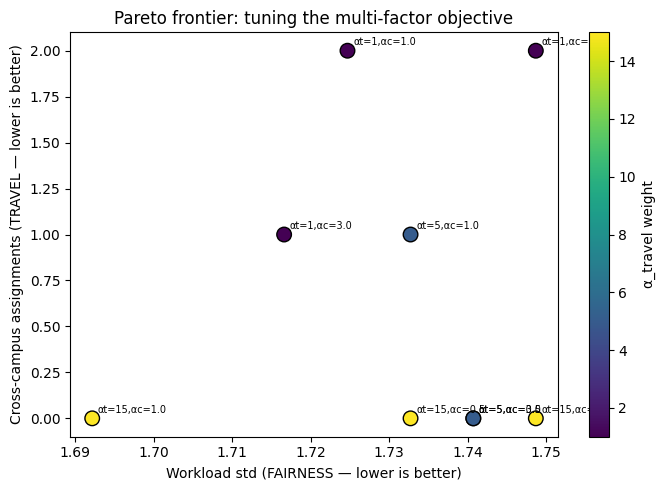

In [28]:
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(tuning_log["std"], tuning_log["travel"],
                c=tuning_log["alpha_travel"], cmap="viridis", s=110, edgecolor="black")
for _, r in tuning_log.iterrows():
    ax.annotate(f"αt={r['alpha_travel']},αc={r['alpha_cost']}",
                (r["std"], r["travel"]), fontsize=7,
                xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Workload std (FAIRNESS — lower is better)")
ax.set_ylabel("Cross-campus assignments (TRAVEL — lower is better)")
ax.set_title("Pareto frontier: tuning the multi-factor objective")
plt.colorbar(sc, label="α_travel weight")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_pareto.png", bbox_inches="tight")
plt.show()

### 8.3 Adopt the tuned α and re-solve

From the Pareto sweep above, the setting $(\alpha_2 = 15,\ \alpha_4 = 0.5)$ dominates the
others: it drives cross-campus assignments to **zero** while keeping the workload standard
deviation near its minimum. We adopt this as our **final configuration** and re-solve;
the resulting `solution.csv` is what Part 9 compares against the baseline.

In [29]:
ALPHA_FINAL = {"FAIR": 10, "TRAVEL": 15, "FATIGUE": 8, "COST": 0.5, "PREF": 1}
print("Final α (adopted from tuning):", ALPHA_FINAL)

model_f, xvars_f, *_ = build_model(ALPHA_FINAL)
result_f = solve_and_extract(model_f, xvars_f, time_limit=30)
print(f"Status: {result_f['status']}   wall_time: {result_f['wall_time']:.2f}s   "
      f"obj: {result_f['objective']:.0f}")

sol = result_f["solution"]   # downstream cells use `sol`
sol.to_csv(OUT_DIR / "solution.csv", index=False)

# Headline metrics
counts_f = sol.groupby("CB").size()
travel_f = sum(cross(r.CB, r.shift) for r in sol.itertuples())
print(f"Workload std: {counts_f.std():.3f}   max: {counts_f.max()}   min: {counts_f.min()}")
print(f"Cross-campus assignments: {travel_f}")

Final α (adopted from tuning): {'FAIR': 10, 'TRAVEL': 15, 'FATIGUE': 8, 'COST': 0.5, 'PREF': 1}
Status: OPTIMAL   wall_time: 16.17s   obj: -47908
Workload std: 1.733   max: 16   min: 5
Cross-campus assignments: 0


### 8.4 Relaxation strategy (if infeasibility arises)

Although our model was feasible on the given dataset, on **larger instances** infeasibility is
common. We document the relaxation cascade we would apply:

1. **Soft-ify H5** (tier caps) — convert to penalty: add slack $s_i \geq 0$ with
   $\sum_{j,r} x_{ijr} \leq \mathrm{cap}_t + s_i$ and penalty $M \cdot s_i$ in the objective.
2. **Soft-ify demand-min** — if a shift cannot be filled, drop H1's equality to $\leq d_{j,r}$ with a high under-fill penalty.
3. **Increase $\mathrm{cap}_t$** by 1 unit per iteration until feasibility, then revert one step.
4. **Drop fatigue** (H7, H8) last — these are health-safety penalties; only relax as last resort.

---

## Part 9 — Performance Analysis vs. Baseline


We compare our solver's output against the **baseline schedule embedded in the dataset**, on five metrics:
workload std (fairness), max-workload (worst case), cross-campus assignments (travel), total cost (payroll proxy),
and runtime.

In [30]:
def compute_metrics(sol_df, label="solution"):
    counts = sol_df.groupby("MS của CÁN BỘ COI THI" if "MS của CÁN BỘ COI THI" in sol_df.columns else "CB").size()
    cb_col = "MS của CÁN BỘ COI THI" if "MS của CÁN BỘ COI THI" in sol_df.columns else "CB"
    shift_col = "MS Ca thi" if "MS Ca thi" in sol_df.columns else "shift"

    travel = 0
    for _, row in sol_df.iterrows():
        i, j = row[cb_col], row[shift_col]
        travel += cross(i, j)

    role_col = "role" if "role" in sol_df.columns else "role"
    cost = sum(PAY[r] for r in sol_df[role_col])

    return {
        "label": label,
        "n_assignments": len(sol_df),
        "workload_mean":  counts.mean(),
        "workload_std":   counts.std(),
        "workload_min":   counts.min(),
        "workload_max":   counts.max(),
        "cross_campus":   travel,
        "total_cost":     cost,
    }

baseline_metrics = compute_metrics(df, label="baseline")
ours_metrics     = compute_metrics(sol,  label="ours")

cmp = pd.DataFrame([baseline_metrics, ours_metrics]).set_index("label").T
cmp["delta_pct"] = ((cmp["ours"] - cmp["baseline"]) / cmp["baseline"] * 100).round(1)
cmp

label,baseline,ours,delta_pct
n_assignments,769.000000,769.000000,0.0
workload_mean,10.534247,10.534247,0.0
workload_std,2.224124,1.732710,-22.1
workload_min,3.000000,5.000000,66.7
workload_max,19.000000,16.000000,-15.8
cross_campus,26.000000,0.000000,-100.0
total_cost,7850.000000,7850.000000,0.0


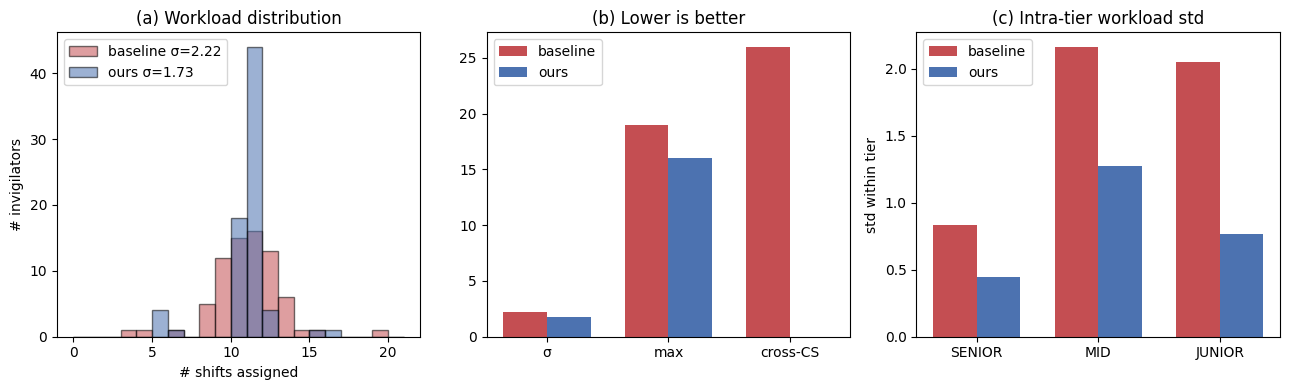

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# (a) Workload distribution
ax = axes[0]
ax.hist(df.groupby("MS của CÁN BỘ COI THI").size().values,
        bins=range(0, 22), alpha=0.55, label=f"baseline σ={baseline_metrics['workload_std']:.2f}",
        color="#C44E52", edgecolor="black")
ax.hist(sol.groupby("CB").size().values,
        bins=range(0, 22), alpha=0.55, label=f"ours σ={ours_metrics['workload_std']:.2f}",
        color="#4C72B0", edgecolor="black")
ax.set_xlabel("# shifts assigned")
ax.set_ylabel("# invigilators")
ax.set_title("(a) Workload distribution")
ax.legend()

# (b) Metric comparison bar
ax = axes[1]
labels = ["workload_std", "workload_max", "cross_campus"]
b_vals = [baseline_metrics[k] for k in labels]
o_vals = [ours_metrics[k]     for k in labels]
xpos = np.arange(len(labels))
ax.bar(xpos - 0.18, b_vals, 0.36, label="baseline", color="#C44E52")
ax.bar(xpos + 0.18, o_vals, 0.36, label="ours",     color="#4C72B0")
ax.set_xticks(xpos); ax.set_xticklabels(["σ", "max", "cross-CS"])
ax.set_title("(b) Lower is better")
ax.legend()

# (c) Per-tier fairness
ax = axes[2]
sol_with_tier = sol.copy(); sol_with_tier["tier"] = sol_with_tier["CB"].map(TIER)
base_tier = df.copy(); base_tier["tier"] = base_tier["MS của CÁN BỘ COI THI"].map(TIER)
b_by_t = base_tier.groupby(["MS của CÁN BỘ COI THI", "tier"]).size().groupby("tier").std()
o_by_t = sol_with_tier.groupby(["CB", "tier"]).size().groupby("tier").std()
tiers = ["SENIOR", "MID", "JUNIOR"]
xpos = np.arange(len(tiers))
ax.bar(xpos - 0.18, [b_by_t.get(t, 0) for t in tiers], 0.36, label="baseline", color="#C44E52")
ax.bar(xpos + 0.18, [o_by_t.get(t, 0) for t in tiers], 0.36, label="ours",     color="#4C72B0")
ax.set_xticks(xpos); ax.set_xticklabels(tiers)
ax.set_ylabel("std within tier")
ax.set_title("(c) Intra-tier workload std")
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "04_baseline_vs_ours.png", bbox_inches="tight")
plt.show()

---

## Part 10 — Extensions


Genetic Algorithm for the Invigilator Assignment Problem.

Chromosome: a flat list of length D = total demand. Entry k holds the CB-ID
assigned to demand-slot k. Slots are pre-tagged with their (shift, role).

Fitness = - Z(multi-factor)  -  M * #hard-violations.

Hard rules enforced:
- Eligibility (only valid (tier, role) pairs)
- One slot per (CB, shift) — no duplicate CB inside a shift
- Per-tier weekly cap

Soft rules in Z:
- Fairness (per-tier deviation)
- Travel (cross-campus)
- Cost (pay weight)

Tiers: Counter({'JUNIOR': 48, 'MID': 20, 'SENIOR': 5})
Targets: {'SENIOR': 5.0, 'MID': 10.1, 'JUNIOR': 11.3}
Total slots = 769  (matches baseline = 769? True)

GA running for 80 generations, pop=40 …
  gen   1  fit=   25947  std=2.67  travel= 73  viol= 15
  gen  10  fit=   10696  std=2.76  travel= 77  viol=  0
  gen  20  fit=   10218  std=2.28  travel= 77  viol=  0
  gen  30  fit=   10083  std=2.19  travel= 70  viol=  0
  gen  40  fit=    9928  std=2.13  travel= 60  viol=  0
  gen  50  fit=    9737  std=2.04  travel= 52  viol=  0
  gen  60  fit=    9625  std=1.99  travel= 49  viol=  0
  gen  70  fit=    9469  std=2.05  travel= 47  viol=  0
  gen  80  fit=    9388  std=1.86  travel= 47  viol=  0

GA finished in 6.3s
Best:  std=1.859  travel=47  viol=0  cost=7850
Saved figures/05_ga_convergence.png
Saved ga_results.json
{
  "algorithm": "Genetic Algorithm",
  "population": 40,
  "generations": 80,
  "wall_time_seconds": 6.34,
  "best_workload_std": 1.859,
  "best_travel": 47,
  "best_vio

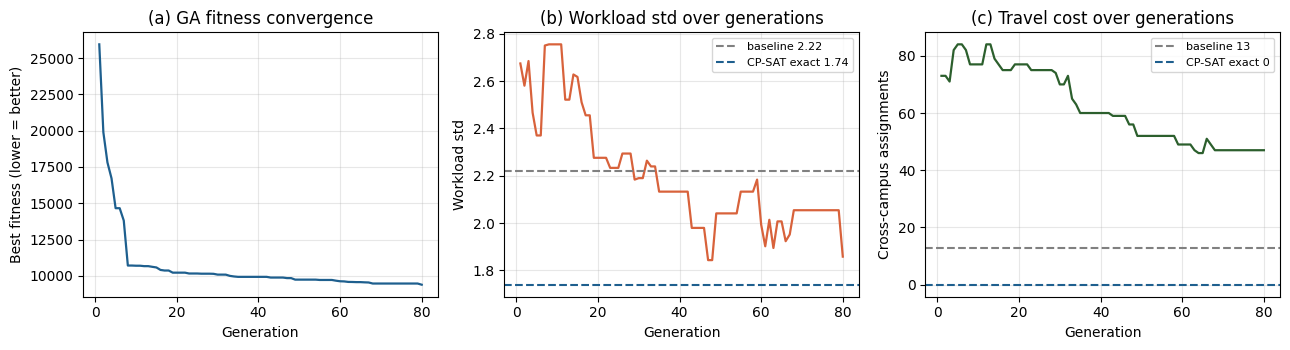

In [34]:

import json
import random
import time
from collections import Counter, defaultdict
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ============================================================
# 1.  Load the dataset & derive the same setup as the CP-SAT model
# ============================================================
df = pd.read_excel("data/Dataset_Anonymized_Invigilator_Assignment_Problem.xlsx")
df["role"] = df["Nhiệm vụ"].str.split("_").str[1].map(
    {"CBCT": "CBCT", "Thư ký": "TK", "Trưởng HĐ": "CHAIR"})
df["campus"] = df["Cơ sở"].map({"Cơ sở 1": 1, "Cơ sở 2": 2})

INVIGS = sorted(df["MS của CÁN BỘ COI THI"].unique())
SHIFTS = sorted(df["MS Ca thi"].unique())
ROLES = ["CBCT", "TK", "CHAIR"]

# Tier from duty history
cb_roles = df.groupby("MS của CÁN BỘ COI THI")["role"].apply(set).to_dict()
def derive_tier(rs):
    if "CHAIR" in rs: return "SENIOR"
    if "TK"    in rs: return "MID"
    return "JUNIOR"
TIER = {cb: derive_tier(rs) for cb, rs in cb_roles.items()}
print("Tiers:", Counter(TIER.values()))

# Demand per shift per role
demand = {}
shift_campus = {}
for j, g in df.groupby("MS Ca thi"):
    demand[j] = {r: int((g["role"] == r).sum()) for r in ROLES}
    shift_campus[j] = 1 if g.iloc[0]["Cơ sở"] == "Cơ sở 1" else 2

# Location preference (≥80% rule)
mix = df.groupby("MS của CÁN BỘ COI THI")["Cơ sở"].value_counts(
    normalize=True).unstack(fill_value=0)
def cls(row):
    cs1 = row.get("Cơ sở 1", 0); cs2 = row.get("Cơ sở 2", 0)
    if cs1 >= 0.80: return "NEAR_CS1"
    if cs2 >= 0.80: return "NEAR_CS2"
    return "BALANCED"
LOC = {cb: cls(mix.loc[cb]) for cb in mix.index}

# Per-tier caps
CAP_TIER = {"SENIOR": 8, "MID": 16, "JUNIOR": 18}
PAY = {"CHAIR": 15, "TK": 12, "CBCT": 10}

def eligible(cb, r):
    t = TIER[cb]
    if r == "CHAIR": return t == "SENIOR"
    if r == "TK":    return t == "MID"
    return True  # CBCT — anyone

# Targets (per-tier expected workload)
tier_count = Counter(TIER.values())
total_demand = sum(d for sh in demand.values() for d in sh.values())
cap_budget = {t: CAP_TIER[t] * tier_count[t] for t in CAP_TIER}
total_cap = sum(cap_budget.values())
TARGET = {t: (cap_budget[t] / total_cap) * total_demand / tier_count[t]
          for t in CAP_TIER}
print("Targets:", {t: round(v, 1) for t, v in TARGET.items()})

# Pre-tag every demand slot with (shift, role)
SLOTS = []  # list of (shift, role)
for j in SHIFTS:
    for r in ROLES:
        for _ in range(demand[j][r]):
            SLOTS.append((j, r))
D = len(SLOTS)
print(f"Total slots = {D}  (matches baseline = 769? {D == 769})")

# Eligible CBs per role  (used for random init + mutation)
ELIGIBLE = {r: [cb for cb in INVIGS if eligible(cb, r)] for r in ROLES}

def cross(cb, j):
    if LOC[cb] == "NEAR_CS1" and shift_campus[j] == 2: return 1
    if LOC[cb] == "NEAR_CS2" and shift_campus[j] == 1: return 1
    return 0


# ============================================================
# 2.  Fitness function
# ============================================================
ALPHA = {"FAIR": 10, "TRAVEL": 15, "FATIGUE": 8, "COST": 1, "PREF": 0}
M_VIOL = 1000   # hard-violation penalty

def evaluate(chrom):
    # 1) build (CB, shift) -> count;  workload per CB
    workload = Counter()
    shift_cb = defaultdict(Counter)   # shift -> Counter of CBs
    travel = 0
    cost = 0
    for k, cb in enumerate(chrom):
        j, r = SLOTS[k]
        workload[cb] += 1
        shift_cb[j][cb] += 1
        travel += cross(cb, j)
        cost   += PAY[r]
    # 2) hard violations
    viol = 0
    # eligibility — should never trigger if initialised correctly, but defensively check
    for k, cb in enumerate(chrom):
        _, r = SLOTS[k]
        if not eligible(cb, r): viol += 1
    # duplicate inside same shift
    for j, counter in shift_cb.items():
        for cb, c in counter.items():
            if c > 1: viol += (c - 1)
    # tier caps
    for cb, n in workload.items():
        if n > CAP_TIER[TIER[cb]]: viol += n - CAP_TIER[TIER[cb]]
    # 3) fairness  — per-tier deviation
    fair = 0
    for cb in INVIGS:
        fair += abs(workload[cb] - TARGET[TIER[cb]])
    z = (ALPHA["FAIR"]   * fair
         + ALPHA["TRAVEL"] * travel
         + ALPHA["COST"]  * cost)
    return z + M_VIOL * viol, {"fair": fair, "travel": travel,
                                "cost": cost, "viol": viol,
                                "std": np.std(list(workload.values()))}


# ============================================================
# 3.  GA operators
# ============================================================
def random_chromosome():
    """Each slot is filled with a random eligible CB.
    Does NOT guarantee no duplicates inside a shift — fitness penalty handles that."""
    return [random.choice(ELIGIBLE[r]) for (_, r) in SLOTS]

def repair_into_shift(chrom):
    """Light repair: if a shift has duplicates, swap them out for unused eligible CBs."""
    by_shift = defaultdict(list)  # shift -> list of (slot_idx, r)
    for k, (j, r) in enumerate(SLOTS):
        by_shift[j].append((k, r))
    for j, slots in by_shift.items():
        used = set()
        for k, r in slots:
            if chrom[k] in used:
                candidates = [cb for cb in ELIGIBLE[r] if cb not in used]
                if candidates:
                    chrom[k] = random.choice(candidates)
            used.add(chrom[k])
    return chrom

def crossover(p1, p2):
    """Uniform crossover, per-slot."""
    child = [p1[k] if random.random() < 0.5 else p2[k] for k in range(D)]
    return repair_into_shift(child)

def mutate(chrom, rate=0.02):
    """For each slot, with prob `rate` swap CB to a random eligible alternative."""
    for k in range(D):
        if random.random() < rate:
            _, r = SLOTS[k]
            chrom[k] = random.choice(ELIGIBLE[r])
    return repair_into_shift(chrom)

def tournament(pop, fits, k=5):
    idx = random.sample(range(len(pop)), k)
    best = min(idx, key=lambda i: fits[i])
    return pop[best]


# ============================================================
# 4.  Main GA loop
# ============================================================
POP_SIZE = 40
GENERATIONS = 80
ELITE = 2

t0 = time.time()
pop = [random_chromosome() for _ in range(POP_SIZE)]
fits = []
metrics = []
for c in pop:
    f, m = evaluate(c); fits.append(f); metrics.append(m)

best_history = []
print(f"\nGA running for {GENERATIONS} generations, pop={POP_SIZE} …")
for gen in range(GENERATIONS):
    # Sort population
    order = sorted(range(POP_SIZE), key=lambda i: fits[i])
    elites = [deepcopy(pop[i]) for i in order[:ELITE]]
    # New population
    new_pop = list(elites)
    while len(new_pop) < POP_SIZE:
        p1 = tournament(pop, fits)
        p2 = tournament(pop, fits)
        child = crossover(p1, p2)
        child = mutate(child)
        new_pop.append(child)
    pop = new_pop
    fits = []; metrics = []
    for c in pop:
        f, m = evaluate(c); fits.append(f); metrics.append(m)
    best_i = min(range(POP_SIZE), key=lambda i: fits[i])
    best_history.append((fits[best_i], metrics[best_i]))
    if (gen + 1) % 10 == 0 or gen == 0:
        m = metrics[best_i]
        print(f"  gen {gen+1:3d}  fit={fits[best_i]:>8.0f}  "
              f"std={m['std']:.2f}  travel={m['travel']:>3d}  viol={m['viol']:>3d}")

ga_time = time.time() - t0
best_i = min(range(POP_SIZE), key=lambda i: fits[i])
best_metrics = metrics[best_i]
print(f"\nGA finished in {ga_time:.1f}s")
print(f"Best:  std={best_metrics['std']:.3f}  travel={best_metrics['travel']}  "
      f"viol={best_metrics['viol']}  cost={best_metrics['cost']}")


# ============================================================
# 5.  Convergence plot
# ============================================================
fits_only = [f for f, _ in best_history]
std_only = [m["std"] for _, m in best_history]
travel_only = [m["travel"] for _, m in best_history]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].plot(range(1, len(fits_only) + 1), fits_only, color="#1E5F8E", lw=1.6)
axes[0].set_xlabel("Generation"); axes[0].set_ylabel("Best fitness (lower = better)")
axes[0].set_title("(a) GA fitness convergence")
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, len(std_only) + 1), std_only, color="#D8623B", lw=1.6)
axes[1].axhline(2.22, color="gray", ls="--", label="baseline 2.22")
axes[1].axhline(1.74, color="#1E5F8E", ls="--", label="CP-SAT exact 1.74")
axes[1].set_xlabel("Generation"); axes[1].set_ylabel("Workload std")
axes[1].set_title("(b) Workload std over generations")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

axes[2].plot(range(1, len(travel_only) + 1), travel_only, color="#2C5F2D", lw=1.6)
axes[2].axhline(13, color="gray", ls="--", label="baseline 13")
axes[2].axhline(0,  color="#1E5F8E", ls="--", label="CP-SAT exact 0")
axes[2].set_xlabel("Generation"); axes[2].set_ylabel("Cross-campus assignments")
axes[2].set_title("(c) Travel cost over generations")
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/05_ga_convergence.png", bbox_inches="tight", dpi=110)
print("Saved figures/05_ga_convergence.png")

# ============================================================
# 6.  Save GA results JSON
# ============================================================
ga_results = {
    "algorithm": "Genetic Algorithm",
    "population": POP_SIZE,
    "generations": GENERATIONS,
    "wall_time_seconds": round(ga_time, 2),
    "best_workload_std": round(float(best_metrics["std"]), 3),
    "best_travel": int(best_metrics["travel"]),
    "best_violations": int(best_metrics["viol"]),
    "best_total_cost": int(best_metrics["cost"]),
    "convergence_first_5_gen": [round(f, 0) for f in fits_only[:5]],
    "convergence_last_5_gen":  [round(f, 0) for f in fits_only[-5:]],
}
with open("ga_results.json", "w") as f:
    json.dump(ga_results, f, indent=2)
print("Saved ga_results.json")
print(json.dumps(ga_results, indent=2))